# Quantum Intrusion Detection System (QIDS) - Data Preprocessing
---
#### Introduction & Data Loading

This notebook serves as the main environment for preparing the NSL-KDD dataset, which will be used in the context of the paper for training quantum algorithms.

First, we load the raw data (.txt) and define the column names. Then, for convenience and future speed, we save a copy in .csv format. Although our analysis will be directly based on DataFrames (internal memory), this file will facilitate visual inspection of the data.

In [125]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import TargetEncoder
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Αν ο τρέχων φάκελος είναι ο 'notebooks', πήγαινε έναν φάκελο πίσω (στο root)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Τρέχων φάκελος εργασίας: {os.getcwd()}")


Τρέχων φάκελος εργασίας: /home/aggelos/Documents/projects/Quantum-IDS-NSLKDD


**Defining column names, as the initial dataset does not contain headers**

In [126]:
col_names = [
'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

**Loading the dataset**

In [127]:
df = pd.read_csv('data/KDDTrain+_20Percent.txt', sep=',', names=col_names)
print(f"Διαστάσεις αρχικού dataset: {df.shape}")
display(df.head()) 

Διαστάσεις αρχικού dataset: (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


**Saving in CSV format for easier future access**

In [128]:
file_path = 'data/KDDTrain+_20Percent.csv'

if not os.path.exists(file_path):
    df.to_csv(file_path, index=False)
    print(f"Το dataset αποθηκεύτηκε επιτυχώς στο: {file_path}")
else:

    print(f"Το αρχείο {file_path} υπάρχει ήδη. Παράλειψη αποθήκευσης.")

Το αρχείο data/KDDTrain+_20Percent.csv υπάρχει ήδη. Παράλειψη αποθήκευσης.


## 1. Data Splitting & Normalization
---
**Stratified Split**:
To evaluate the model, it is necessary to split the dataset into training (Train set) and testing (Test set) sets. To ensure the split is "fair" and representative, we will apply stratification techniques. This ensures that critical features maintain the same distribution in both subsets, preventing the model from ignoring rare attacks.

**Normalization**:
Network features have completely different measurement scales (e.g., bytes versus percentage rates). It is crucial to normalize this information to a common scale so they are comparable and can be efficiently fed into quantum circuits (Qubits).

#### Feature Extraction: Packet Size Categorization (src_bytes_cat)

For a proper stratified split, we select two main axes:
1. **Traffic Label**: The most fundamental metric, as it determines the nature of the traffic (normal or attack).
2. **Packet Size (Source Bytes)**: Although rarely used as a primary splitting criterion, it provides vital information about the physical nature of the packet. Because packet sizes show huge variance, we will categorize them into groups (bins).

In this way, we label the packets as low, medium, or high depending on their data volume. This ensures our model will be trained and tested under identical network traffic conditions.

Following steps:
* Creation of the new categorical size variable.
* Application of the split (Train/Test) while preserving the distribution.

#### Splitting src_bytes into 3 equal-frequency intervals (quantiles)

In [129]:
df['src_bytes_cat'] = pd.qcut(df['src_bytes'], q=4, duplicates='drop', labels=['low', 'medium', 'high'])

print("Ποσοστιαία κατανομή κατηγοριών μεγέθους πακέτου:")
print(df['src_bytes_cat'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

Ποσοστιαία κατανομή κατηγοριών μεγέθους πακέτου:
src_bytes_cat
low       50.94%
high      24.96%
medium    24.09%
Name: proportion, dtype: str


#### Checking the boundaries of each category

In [130]:
check_bins = df.groupby('src_bytes_cat', observed=True)['src_bytes'].agg(['min', 'max', 'count'])
print("\nΌρια κατηγοριών (min, max bytes) και πλήθος εγγραφών:")
display(check_bins)


Όρια κατηγοριών (min, max bytes) και πλήθος εγγραφών:


,min,max,count
src_bytes_cat,,,
low,0,44,12834
medium,45,279,6069
high,280,381709090,6289


#### Creating a composite helper column for the stratified split (Label + Size Category)

In [131]:
df['strat_col'] = df['label'].astype(str) + "_" + df['src_bytes_cat'].astype(str)

#### Identifying combinations that appear less than 2 times (impossible to split into train/test)

In [132]:
counts = df['strat_col'].value_counts()
problematic_combinations = counts[counts < 2].index

print(f"Αρχικό πλήθος προβληματικών (σπάνιων) συνδυασμών: {len(problematic_combinations)}")

Αρχικό πλήθος προβληματικών (σπάνιων) συνδυασμών: 12


#### Handling: For rare combinations, we keep only the base Label, omitting the size

In [133]:
mask = df['strat_col'].isin(problematic_combinations)
df.loc[mask, 'strat_col'] = df.loc[mask, 'label']

#### Final Check after correction

In [134]:
final_counts = df['strat_col'].value_counts()
remaining_singles = final_counts[final_counts < 2]

print(f"Εναπομείνασες μοναδικές εγγραφές (που υπάρχουν μόνο μία φορά στο dataset): {len(remaining_singles)}")

if len(remaining_singles) > 0:
    print("\nΠΡΟΣΟΧΗ: Οι παρακάτω επιθέσεις είναι απολύτως μοναδικές στο dataset:")
print(remaining_singles)

Εναπομείνασες μοναδικές εγγραφές (που υπάρχουν μόνο μία φορά στο dataset): 8

ΠΡΟΣΟΧΗ: Οι παρακάτω επιθέσεις είναι απολύτως μοναδικές στο dataset:
strat_col
portsweep      1
ftp_write      1
warezmaster    1
land           1
loadmodule     1
satan          1
spy            1
ipsweep        1
Name: count, dtype: int64


#### Outlier Handling

The rare attacks identified above (which appear only once in the entire dataset) represent a special case.

To ensure our model encounters them during training, they will be isolated and introduced exclusively into the Training Set. The remaining "normal" volume of data will be split regularly using the 80-20 method.

#### Separating unique records from the core dataset

In [135]:
single_mask = df['strat_col'].isin(remaining_singles.index)
df_singles = df[single_mask]     # Σπάνιες εγγραφές (Μόνο για Train)
df_majority = df[~single_mask]   # Κύριος όγκος δεδομένων (Προς διαχωρισμό)

#### Strategic 80-20 split on the main volume

In [136]:
train_majority, test_set = train_test_split(
df_majority,
test_size=0.2,
random_state=42,
stratify=df_majority['strat_col']
)

#### Reattaching rare records to the Training Set

In [137]:
train_set = pd.concat([train_majority, df_singles])

#### Removing the 'strat_col' helper column as it has served its purpose

In [138]:
test_set = test_set.drop(columns=['strat_col'])
train_set = train_set.drop(columns=['strat_col'])
df = df.drop(columns=['strat_col'], errors='ignore')

print(f"Διαστάσεις τελικού Training Set: {train_set.shape}")
print(f"Διαστάσεις τελικού Test Set: {test_set.shape}")

Διαστάσεις τελικού Training Set: (20155, 44)
Διαστάσεις τελικού Test Set: (5037, 44)


#### Separating Features and Labels
We also remove the 'difficulty_level' column as it is not relevant to model creation.

In [139]:
xTrain = train_set.drop(columns=['label', 'difficulty_level'])
yTrain = train_set['label']

xTest = test_set.drop(columns=['label', 'difficulty_level'])
yTest = test_set['label']

## 2. Feature Encoding
---
**Selection**: Target Encoding
Unlike classical techniques such as One-Hot Encoding which cause a massive increase in dimensions (dimensionality explosion), Target Encoding is chosen here with Quantum Economy in mind.

With this technique, each categorical value is replaced by the statistical probability of an attack occurring, as calculated in the training set.
* Example: If TCP receives the value 0.7, it means that 70% of TCP connections in the Train set were malicious attacks. Respectively, if UDP receives 0.2, it means 20%.
* Semantic Value: The comparison 0.7 > 0.2 gives the model immediate information that TCP is statistically more "dangerous", allowing us to condense network information while drastically reducing the required number of Qubits.

**Selecting the columns that require encoding**

In [140]:
categorical_cols = ['protocol_type', 'service', 'flag', 'src_bytes_cat']

**Creating a binary target (0 for normal traffic, 1 for attacks)**
<sub>Note: In NSL-KDD the reference class ends with a dot ('normal.')</sub>

In [141]:
yTrainBinary = np.where(yTrain == 'normal.', 0, 1)

**Initializing Target Encoder, automatic smoothing to avoid overfitting on rare classes**

In [142]:
encoder = TargetEncoder(target_type='binary', smooth="auto")

**Training on the Train set and "blind" transformation on the Test set to avoid Data Leakage**

In [143]:
xTrain_encoded = encoder.fit_transform(xTrain[categorical_cols], yTrainBinary)
xTest_encoded = encoder.transform(xTest[categorical_cols])

**Restoring the encoded arrays to DataFrames**

In [144]:
df_encoded_train = pd.DataFrame(xTrain_encoded, columns=categorical_cols, index=xTrain.index)
df_encoded_test = pd.DataFrame(xTest_encoded, columns=categorical_cols, index=xTest.index)

**Replacing the old categorical columns with the newly encoded ones**

In [145]:
xTrain_final = pd.concat([xTrain.drop(columns=categorical_cols), df_encoded_train], axis=1)
xTest_final = pd.concat([xTest.drop(columns=categorical_cols), df_encoded_test], axis=1)

print(f"Τελικές διαστάσεις Training Set: {xTrain_final.shape}")
print(f"Τελικές διαστάσεις Test Set: {xTest_final.shape}")

Τελικές διαστάσεις Training Set: (20155, 42)
Τελικές διαστάσεις Test Set: (5037, 42)


## 3. Feature Scaling
---
Before applying dimensionality reduction methods (PCA) and feeding data into quantum circuits, it is necessary to normalize the data. We apply StandardScaler, which centers the data around zero (mean = 0) with a standard deviation of 1 (variance = 1), giving us numerical values ideal for PCA.

In [146]:
scaler = StandardScaler()

**Calculating parameters on the Train set and applying them**

In [147]:
xTrain_scaled = scaler.fit_transform(xTrain_final)

**Applying the same parameters to the Test set**

In [148]:
xTest_scaled = scaler.transform(xTest_final)

## 4. Principal Component Analysis (PCA)
---
For Quantum Machine Learning (QML) to function efficiently on today's NISQ systems, we must optimize the available quantum space.

We aim to compress the information into exactly 16 principal components.
This number constitutes the "golden rule" of our architecture, because:
* It allows full utilization of the $2^4$ Hilbert states in just 4 Qubits (for **Amplitude Encoding**).
* It provides a shallow and manageable 16 Qubit circuit (for **Angle Encoding**) for very fast simulations with low noise.

**Defining PCA targeting 16 components**

In [149]:
pca = PCA(n_components=16)

xTrain_pca = pca.fit_transform(xTrain_scaled)
xTest_pca = pca.transform(xTest_scaled)

**Evaluating the retained information**

In [150]:
explained_variance = pca.explained_variance_ratio_.sum()

print(f"Ποσοστό πληροφορίας που διατηρήθηκε (Explained Variance): {explained_variance:.2%}")
print("Στόχος επετεύχθη: Διαμόρφωση 16 στηλών, έτοιμες για κβαντική ενσωμάτωση (Amplitude: 4 Qubits | Angle: 16 Qubits).")

Ποσοστό πληροφορίας που διατηρήθηκε (Explained Variance): 86.78%
Στόχος επετεύχθη: Διαμόρφωση 16 στηλών, έτοιμες για κβαντική ενσωμάτωση (Amplitude: 4 Qubits | Angle: 16 Qubits).


## 5. Quantum Data Encoding
---
**Amplitude Encoding**
Instead of needing 16 qubits for 16 features, we encode the information into the probability amplitudes of the quantum state. Thus, we can fit $2^\nu$ features into $\nu$ qubits. To load the data into a quantum state, the vector of each record must be normalized so that the sum of the squares of its elements equals 1.

In [151]:
from sklearn.preprocessing import normalize
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

**L2 normalization (each row separately)**

In [152]:
xTrain_norm = normalize(xTrain_pca, norm='l2', axis=1)
xTest_norm = normalize(xTest_pca, norm='l2', axis=1)
l2_norm_check = np.linalg.norm(xTrain_norm[0])
print(f"L2 Norm της πρώτης εγγραφής μετά την κανονικοποίηση: {l2_norm_check:.4f}")

L2 Norm της πρώτης εγγραφής μετά την κανονικοποίηση: 1.0000


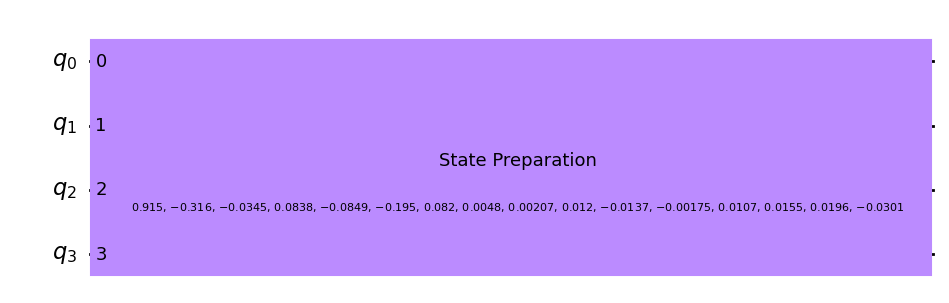

In [153]:
num_qubits = 4
smaple_data = xTrain_norm[0]  
state_prep = StatePreparation(smaple_data)
qc = QuantumCircuit(num_qubits, name="Amplitude encoding")
qc.append(state_prep, range(num_qubits))
qc.draw(output='mpl', style='clifford')

### 5.1 Quantum Model Design (Amplitude VQC Architecture)
---
Here we synthesize the final architecture of our model exclusively for 4-qubit Amplitude encoding.
**Feature Map** (RawFeatureVector): A specialized Qiskit circuit that takes 16 features and automatically converts them into a 4-Qubit quantum state.
**Ansatz** (RealAmplitudes): The parameterized circuit that acts as the "neural network" and will be trained. Because we only have 4 qubits, we will give it greater depth so it has more parameters and can learn more complex patterns in the attacks.

Απαιτούμενα Qubits:4
Αριθμός παραμέτρων ansatz: 28


/tmp/ipykernel_8696/3573747456.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz_amp=RealAmplitudes(num_qubits=4, reps=2)


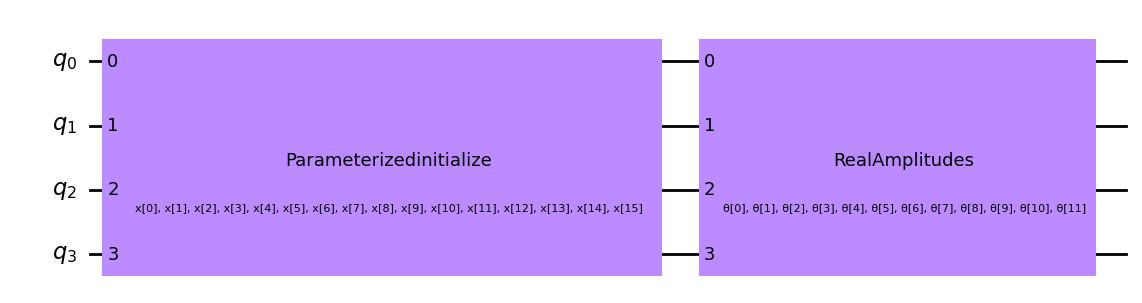

In [154]:
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit.circuit.library import RealAmplitudes

feature_vector_circuit = raw_feature_vector(feature_dimension=16)
ansatz_amp=RealAmplitudes(num_qubits=4, reps=2)
vqc_amp = feature_vector_circuit.compose(ansatz_amp)
print(f'Απαιτούμενα Qubits:{vqc_amp.num_qubits}')
print(f'Αριθμός παραμέτρων ansatz: {vqc_amp.num_parameters}')
vqc_amp.draw(output='mpl', style='clifford')

### 5.2 Optimizer Selection: Why COBYLA?
---
To train our quantum model (VQC), we need an optimization algorithm (Optimizer). Its role is to find the ideal values for the unknown angles (the trainable weights $\theta$) of the Ansatz, in order to minimize the error (loss) in the model's predictions.

In this specific architectural scheme (Amplitude Encoding), we choose **COBYLA** (Constrained Optimization BY Linear Approximations) for a very specific, technical reason:

1. **The Gradient "Trap":** Most classical optimizers (like Adam in Neural Networks) rely on calculating derivatives (gradient descent). They use the slope of the error function to understand which way to adjust the weights. However, the `raw_feature_vector` function we use relies on the `initialize()` quantum instruction. This instruction does not support analytical differentiation in Qiskit. If we used a gradient-based optimizer, the training would fail.
2. **The COBYLA Solution (Gradient-Free Optimization):** COBYLA belongs to the category of *gradient-free* algorithms, meaning it does not need to calculate derivatives.
3. **How it works (The Simplex method):** Instead of derivatives, COBYLA builds linear approximations. It creates a conceptual geometric shape (Simplex) in the weight space. It evaluates the error at the vertices of this shape (by doing trial executions of the circuit) and "guesses" in which direction the smallest error lies. Then, it "moves" its shape in that direction, gradually updating the weights $\theta$.

This mathematical approach makes COBYLA the most reliable and inevitable choice for circuits performing direct State Preparation.

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Ξεκινάει η ΚΑΝΟΝΙΚΗ εκπαίδευση σε 20155 δείγματα...

Η εκπαίδευση ολοκληρώθηκε επιτυχώς σε 156.19 λεπτά!

Το κβαντικό μοντέλο εξετάζει το FULL Test Set...

Συνολική Ακρίβεια (Accuracy): 87.81%

--- Αναλυτική Αναφορά (Classification Report) ---
              precision    recall  f1-score   support

  Normal (0)       0.89      0.88      0.89      2690
  Attack (1)       0.87      0.87      0.87      2347

    accuracy                           0.88      5037
   macro avg       0.88      0.88      0.88      5037
weighted avg       0.88      0.88      0.88      5037



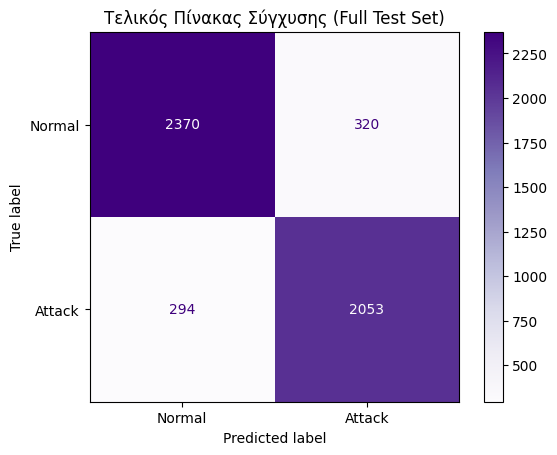

In [155]:
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit.circuit.library import real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import time

# 1. ΠΛΗΡΗ ΔΕΔΟΜΕΝΑ ΚΑΙ BINARIZATION (Όλα σε ένα βήμα για να μην έχουμε NameError)
# Αν είναι 'normal' γίνεται 0, αν είναι οτιδήποτε άλλο (επίθεση) γίνεται 1
yTrain_bin = (yTrain != 'normal').astype(int).to_numpy()
yTest_bin = (yTest != 'normal').astype(int).to_numpy()

xTrain_full = xTrain_norm
yTrain_full = yTrain_bin

xTest_full = xTest_norm
yTest_full = yTest_bin

# 2. ΑΥΞΗΣΗ ΒΑΘΟΥΣ ΚΥΚΛΩΜΑΤΟΣ (reps=3 αντί για 2)
feature_vector_circuit = raw_feature_vector(feature_dimension=16)
ansatz_amp = real_amplitudes(num_qubits=4, reps=3)

# 3. ΑΥΞΗΣΗ ΕΠΑΝΑΛΗΨΕΩΝ OPTIMIZER (maxiter=200)
optimizer = COBYLA(maxiter=200)

objective_func_vals = []
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.figure(figsize=(8, 5))
    plt.title("Τελική Εκπαίδευση VQC (Full Dataset - Reps:3)")
    plt.xlabel("Επανάληψη (Iteration)")
    plt.ylabel("Σφάλμα (Objective Function Loss)")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, color='purple', linewidth=2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

vqc_amp_model_final = VQC(
    feature_map=feature_vector_circuit,
    ansatz=ansatz_amp,
    optimizer=optimizer,
    callback=callback_graph
)

# 4. ΤΕΛΙΚΗ ΕΚΠΑΙΔΕΥΣΗ (Θα πάρει αρκετή ώρα!)
print(f"Ξεκινάει η ΚΑΝΟΝΙΚΗ εκπαίδευση σε {len(xTrain_full)} δείγματα...")
start_time = time.time()

vqc_amp_model_final.fit(xTrain_full, yTrain_full)

end_time = time.time()
print(f"\nΗ εκπαίδευση ολοκληρώθηκε επιτυχώς σε {(end_time - start_time)/60:.2f} λεπτά!")

# 5. ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ
print("\nΤο κβαντικό μοντέλο εξετάζει το FULL Test Set...")
y_pred_full = vqc_amp_model_final.predict(xTest_full)
test_score_full = vqc_amp_model_final.score(xTest_full, yTest_full)

print(f"\nΣυνολική Ακρίβεια (Accuracy): {test_score_full * 100:.2f}%\n")
print("--- Αναλυτική Αναφορά (Classification Report) ---")
print(classification_report(yTest_full, y_pred_full, target_names=["Normal (0)", "Attack (1)"]))

# 6. Τελικό Confusion Matrix
cm = confusion_matrix(yTest_full, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(cmap='Purples')
plt.title("Τελικός Πίνακας Σύγχυσης (Full Test Set)")
plt.show()

In [157]:
# Αποθήκευση του εκπαιδευμένου μοντέλου στο φάκελο που βρίσκεσαι
vqc_amp_model_final.save("vqc_model_200_samples.model")

print("Το μοντέλο αποθηκεύτηκε επιτυχώς στο αρχείο: vqc_model_200_samples.model")

Το μοντέλο αποθηκεύτηκε επιτυχώς στο αρχείο: vqc_model_200_samples.model


/tmp/ipykernel_8696/1308967355.py:2: DeprecationWarning: SerializableModelMixin.save() is deprecated. as of qiskit-machine-learning 0.9.0 and will be removed no sooner than 4 months after the release date. Use the to_dill() method instead.
  vqc_amp_model_final.save("vqc_model_200_samples.model")
